# Week 6 — Final Metrics & Analysis (what to report)
### Test metrics · data-efficiency curve · confidence calibration · Grad-CAM · deployment brief

Macro-F1 ≥ 0.88 — you already done it. This notebook builds each required deliverable end-to-end.

In [1]:
import time, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
%matplotlib inline
SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams.update({"figure.dpi":110,"font.size":10})
print("device:", device)

device: cpu


## 0. A stand-in model to analyse
We need *a trained classifier + a held-out test set* to demonstrate the metrics. On your project this is the
**fine-tuned ResNet-50** and the **PlantVillage test split**. Here it's a small CNN on synthetic shapes
(5 classes, imbalanced, shared colours so the model must learn shape → realistic, imperfect confidences).

In [2]:
CLASSES=["disk","ring","square","triangle","bars"]; N_CLASSES,S=5,40
COUNTS=[600,460,340,220,140]
PAL=np.array([[.82,.33,.33],[.82,.33,.33],[.33,.62,.38],[.33,.62,.38],[.35,.45,.82]])  # shared colours
def gen(cls,rng):
    img=np.full((S,S,3),rng.uniform(.15,.30,3),np.float32); yy,xx=np.mgrid[0:S,0:S]
    cx,cy=rng.uniform(S*.4,S*.6,2); r=rng.uniform(S*.16,S*.24); col=np.clip(PAL[cls]+rng.normal(0,.05,3),0,1)
    if   cls==0: m=(xx-cx)**2+(yy-cy)**2<=r**2
    elif cls==1: d=(xx-cx)**2+(yy-cy)**2; m=(d<=r**2)&(d>=(r*.55)**2)
    elif cls==2: s=r*.9; m=(np.abs(xx-cx)<=s)&(np.abs(yy-cy)<=s)
    elif cls==3: t=np.clip((yy-(cy-r))/(2*r),0,1); m=(np.abs(xx-cx)<=t*r)&(yy>=cy-r)&(yy<=cy+r)
    else:        p=max(2,int(r*.5)); m=((xx//p)%2==0)&(np.abs(xx-cx)<=r)&(np.abs(yy-cy)<=r)
    a=rng.uniform(.55,.78); img[m]=(1-a)*img[m]+a*col                      # faint shapes
    img+=rng.normal(0,.11,(S,S,3)).astype(np.float32); return np.clip(img,0,1).astype(np.float32)
rng=np.random.default_rng(SEED)
X=np.stack([gen(c,rng) for c,n in enumerate(COUNTS) for _ in range(n)]); y=np.array([c for c,n in enumerate(COUNTS) for _ in range(n)])
X_tr,X_tmp,y_tr,y_tmp=train_test_split(X,y,test_size=.30,stratify=y,random_state=SEED)
X_va,X_te,y_va,y_te=train_test_split(X_tmp,y_tmp,test_size=.5,stratify=y_tmp,random_state=SEED)
mean,std=X_tr.mean((0,1,2)),X_tr.std((0,1,2))
def tens(A):
    t=torch.tensor(A).permute(0,3,1,2); return ((t-torch.tensor(mean).view(1,3,1,1))/torch.tensor(std).view(1,3,1,1)).float()
def loader(A,b,bs=64,sh=False): return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(tens(A),torch.tensor(b)),batch_size=bs,shuffle=sh)

class SmallCNN(nn.Module):                       # >>> SWAP: your fine-tuned ResNet-50
    def __init__(s,n,w=24):
        super().__init__()
        blk=lambda i,o: nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.BatchNorm2d(o),nn.ReLU(),nn.MaxPool2d(2))
        s.features=nn.Sequential(blk(3,w),blk(w,2*w),nn.Conv2d(2*w,4*w,3,padding=1),nn.BatchNorm2d(4*w),nn.ReLU())
        s.pool=nn.AdaptiveAvgPool2d(1); s.fc=nn.Linear(4*w,n); s.gradcam_target=s.features[-1]
    def forward(s,x): return s.fc(s.pool(s.features(x)).flatten(1))

def train_on(Xtr,ytr,epochs=12,lr=1e-3):
    torch.manual_seed(SEED); model=SmallCNN(N_CLASSES).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=lr); crit=nn.CrossEntropyLoss()
    tl=loader(Xtr,ytr,sh=True)
    for _ in range(epochs):
        model.train()
        for xb,yb in tl:
            xb,yb=xb.to(device),yb.to(device); opt.zero_grad(); loss=crit(model(xb),yb); loss.backward(); opt.step()
    return model

@torch.no_grad()
def logits_of(model,A):                          # returns logits (N,C) for a numpy image array
    model.eval(); out=[]
    for xb,_ in loader(A,np.zeros(len(A),int)): out.append(model(xb.to(device)).cpu())
    return torch.cat(out)

model=train_on(X_tr,y_tr)
print(f"trained on {len(X_tr)} images | test set: {len(X_te)}")

trained on 1232 images | test set: 264


## Deliverable 1 — Test-set metrics (the headline)
Report on the **held-out test set, once**: overall accuracy, **macro-F1** (the target), **per-class F1**, and a
**confusion matrix**. On 38 imbalanced classes, the confusion matrix is where the story is — *which* diseases the
model confuses. Never report accuracy alone.

Test accuracy : 0.951
Test macro-F1 : 0.932   (target >= 0.88)

              precision    recall  f1-score   support

        disk      1.000     1.000     1.000        90
        ring      1.000     1.000     1.000        69
      square      0.828     0.941     0.881        51
    triangle      0.885     0.697     0.780        33
        bars      1.000     1.000     1.000        21

    accuracy                          0.951       264
   macro avg      0.942     0.928     0.932       264
weighted avg      0.952     0.951     0.949       264



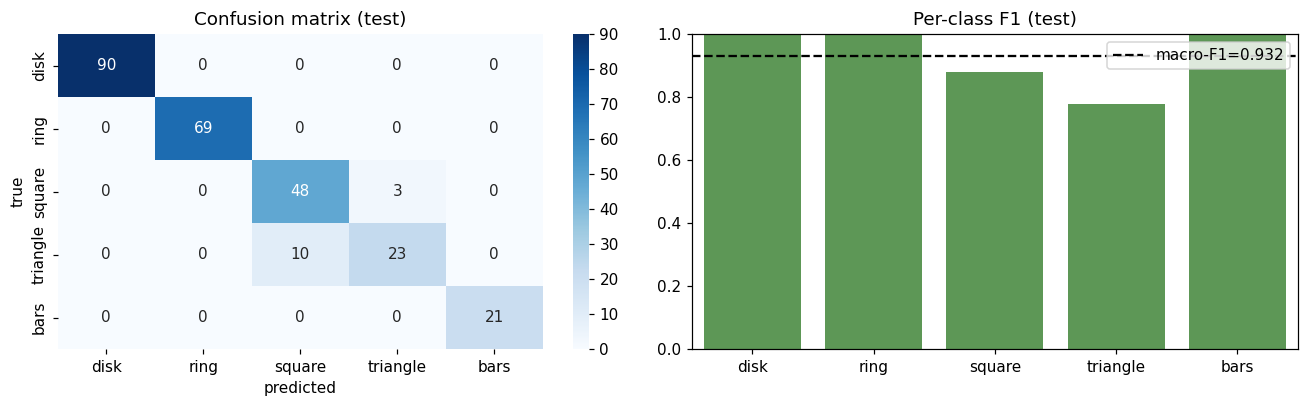

In [3]:
test_logits=logits_of(model,X_te); y_pred=test_logits.argmax(1).numpy()
macro=f1_score(y_te,y_pred,average="macro")
print(f"Test accuracy : {(y_pred==y_te).mean():.3f}")
print(f"Test macro-F1 : {macro:.3f}   (target >= 0.88)\n")
print(classification_report(y_te,y_pred,target_names=CLASSES,digits=3))

fig,ax=plt.subplots(1,2,figsize=(12,3.8))
sns.heatmap(confusion_matrix(y_te,y_pred),annot=True,fmt="d",cmap="Blues",xticklabels=CLASSES,yticklabels=CLASSES,ax=ax[0])
ax[0].set_title("Confusion matrix (test)"); ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true")
sns.barplot(x=CLASSES,y=f1_score(y_te,y_pred,average=None),ax=ax[1],color="#54A24B"); ax[1].set_ylim(0,1)
ax[1].axhline(macro,ls="--",color="k",label=f"macro-F1={macro:.3f}"); ax[1].legend()
ax[1].set_title("Per-class F1 (test)"); plt.tight_layout(); plt.show()

## Deliverable 2 — Data-efficiency curve
*"How much labelled data do we actually need?"* Train the **same model** on growing fractions of the training set
(e.g. 10% → 100%) and plot **test macro-F1 vs. training-set size**. The shape answers a real deployment question:
where do returns flatten, so the extension service knows how much labelling effort buys how much accuracy.

 10% ( 123 imgs) -> test macro-F1 0.482


 25% ( 308 imgs) -> test macro-F1 0.810


 50% ( 616 imgs) -> test macro-F1 0.852


100% (1232 imgs) -> test macro-F1 0.932


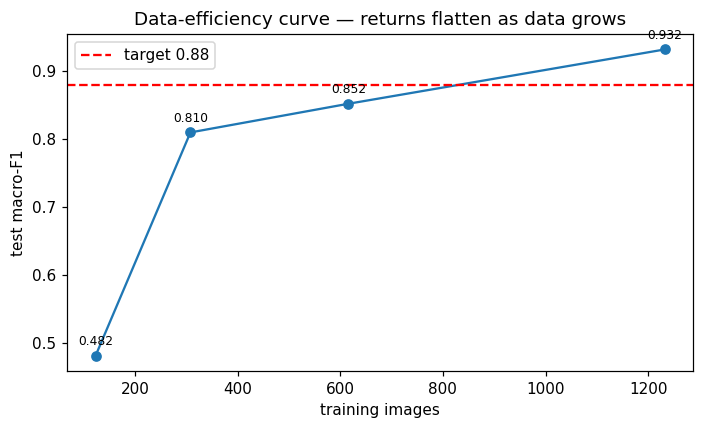

In [4]:
fractions=[0.1,0.25,0.5,1.0]; effs=[]
for fr in fractions:
    if fr<1.0:
        Xf,_,yf,_=train_test_split(X_tr,y_tr,train_size=fr,stratify=y_tr,random_state=SEED)
    else:
        Xf,yf=X_tr,y_tr
    m=train_on(Xf,yf,epochs=12)
    pf=logits_of(m,X_te).argmax(1).numpy()
    effs.append(f1_score(y_te,pf,average="macro")); print(f"{int(fr*100):3d}% ({len(Xf):4d} imgs) -> test macro-F1 {effs[-1]:.3f}")

sizes=[int(fr*len(X_tr)) for fr in fractions]
plt.figure(figsize=(6.5,4)); plt.plot(sizes,effs,"o-")
for xq,yq in zip(sizes,effs): plt.annotate(f"{yq:.3f}",(xq,yq),textcoords="offset points",xytext=(0,7),ha="center",fontsize=8)
plt.axhline(0.88,ls="--",color="r",label="target 0.88"); plt.xlabel("training images"); plt.ylabel("test macro-F1")
plt.title("Data-efficiency curve — returns flatten as data grows"); plt.legend(); plt.tight_layout(); plt.show()

## Deliverable 3 — Confidence calibration
A model's confidence should match its accuracy. It can be **over-confident** (says 0.99 when it's right 80% of the
time) or **under-confident** — either way the probability is untrustworthy, and a tool a farmer relies on needs a
confidence that *means something*. We measure the gap with a **reliability diagram** and **Expected Calibration Error
(ECE)**, then correct it with **temperature scaling** — one parameter `T` fit on the **validation** set (never test).
`T > 1` softens an over-confident model; `T < 1` sharpens an under-confident one.

       M  | B_m |
ECE =  ∑  ───── * | Acc(B_m) - Conf(B_m) |
      m=1   N

m = 1 to 10, val_N = 8k
1) predictions are sorted, divided into equally bins based on probability

0-0.1, 0.2-0.3, .... 0.8-0.9

> Deep nets like your fine-tuned **ResNet-50 are usually over-confident** (expect `T > 1`). This tiny demo model comes
> out slightly *under*-confident (`T < 1`) — the code and the fix are identical either way.

fitted temperature T = 0.492
ECE before: 0.073  |  ECE after temperature scaling: 0.019


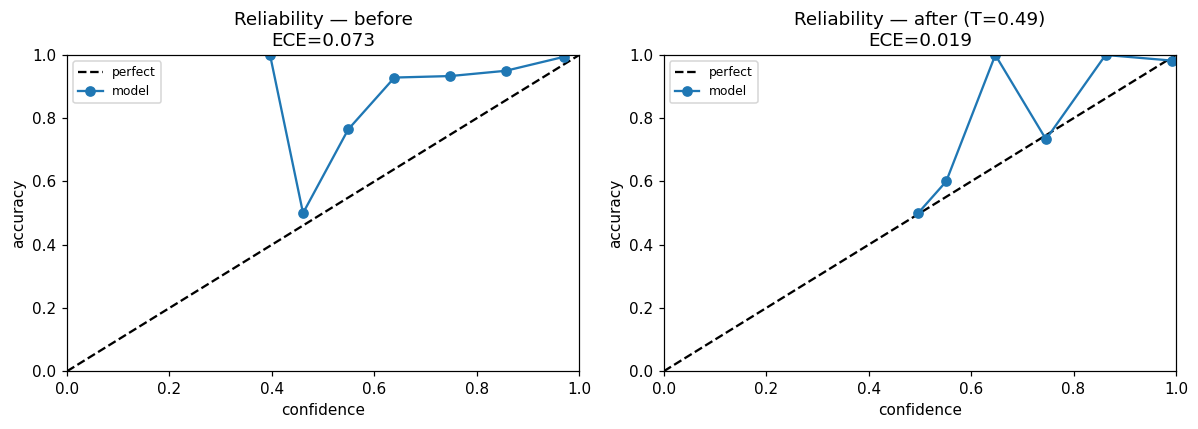

In [ ]:
def softmax_np(z): e=np.exp(z-z.max(1,keepdims=True)); return e/e.sum(1,keepdims=True)
def ece(probs,labels,n_bins=10):
    conf=probs.max(1); pred=probs.argmax(1); acc=(pred==labels).astype(float)
    bins=np.linspace(0,1,n_bins+1); e=0.0; xs=[]; ys=[]
    for lo,hi in zip(bins[:-1],bins[1:]):
        m=(conf>lo)&(conf<=hi)
        if m.sum()>0:
            e+=abs(acc[m].mean()-conf[m].mean())*m.mean(); xs.append(conf[m].mean()); ys.append(acc[m].mean())
    return e,xs,ys

val_logits=logits_of(model,X_va).numpy(); test_logits_np=test_logits.numpy()
# fit temperature T on validation NLL (LBFGS)
T=torch.ones(1,requires_grad=True); optT=torch.optim.LBFGS([T],lr=.05,max_iter=60)
vl=torch.tensor(val_logits); vy=torch.tensor(y_va)
def closure(): optT.zero_grad(); loss=F.cross_entropy(vl/T,vy); loss.backward(); return loss
optT.step(closure); T=float(T.detach()); print(f"fitted temperature T = {T:.3f}")

p_before=softmax_np(test_logits_np); p_after=softmax_np(test_logits_np/T)
e0,x0,y0=ece(p_before,y_te); e1,x1,y1=ece(p_after,y_te)
print(f"ECE before: {e0:.3f}  |  ECE after temperature scaling: {e1:.3f}")

fig,ax=plt.subplots(1,2,figsize=(11,4))
for a,(xs,ys,e,t) in zip(ax,[(x0,y0,e0,"before"),(x1,y1,e1,f"after (T={T:.2f})")]):
    a.plot([0,1],[0,1],"k--",label="perfect"); a.plot(xs,ys,"o-",label="model")
    a.set_title(f"Reliability — {t}\nECE={e:.3f}"); a.set_xlabel("confidence"); a.set_ylabel("accuracy")
    a.set_xlim(0,1); a.set_ylim(0,1); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

if T>1 soften the model, because its over confident 
if T < 1 sharpen the model, because its under confident

## Deliverable 4 — Grad-CAM disease localisation
Does the model look at the **lesion**, or at the background/pot/hand? Grad-CAM highlights the pixels that drove the
prediction. This is your defence against the PlantVillage **background-bias** trap — if the heatmap sits on the
leaf lesion, that's evidence the model learned disease, not the photo setup.

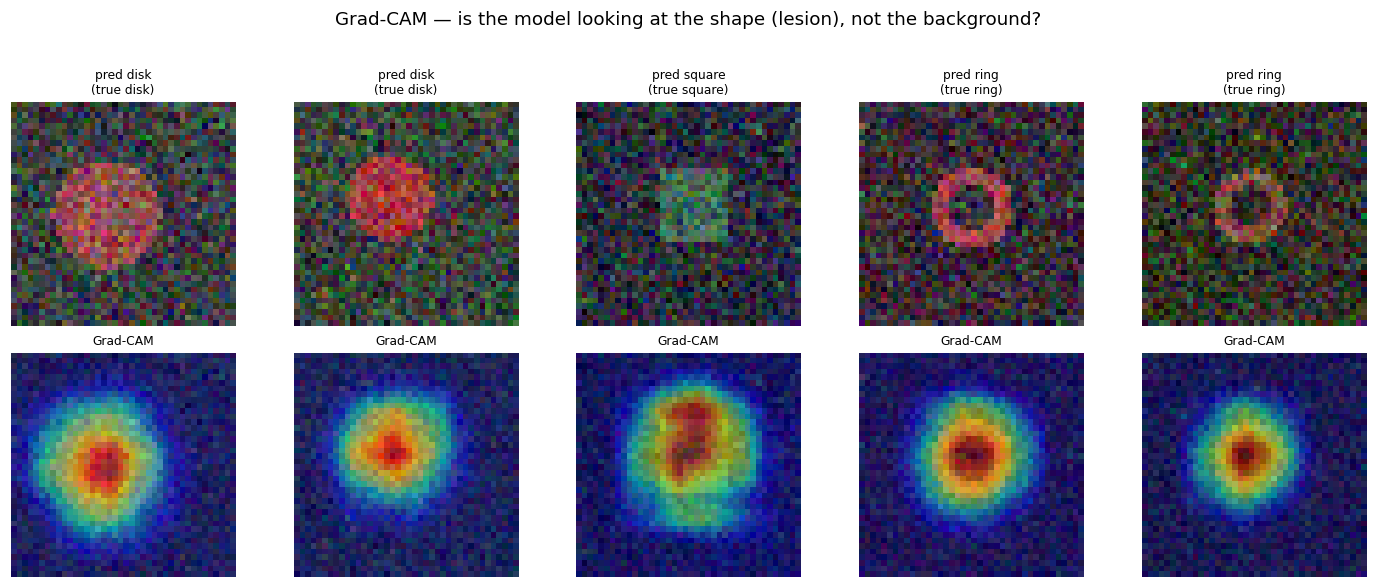

In [6]:
def grad_cam(model,x,cls,layer):
    acts={}; grads={}
    def fwd(m,i,o): acts["v"]=o            # hooks must return None
    def bwd(m,gi,go): grads["v"]=go[0]
    h1=layer.register_forward_hook(fwd)
    h2=layer.register_full_backward_hook(bwd)
    model.eval(); model.zero_grad()
    out=model(x); out[0,cls].backward()
    A=acts["v"][0].detach(); G=grads["v"][0].detach()
    cam=torch.relu((G.mean((1,2))[:,None,None]*A).sum(0)); cam=(cam/ (cam.max()+1e-8)).cpu().numpy()
    h1.remove(); h2.remove(); return cam

rng2=np.random.default_rng(1); idx=rng2.choice(len(X_te),5,replace=False)
fig,ax=plt.subplots(2,5,figsize=(13,5.2))
for j,i in enumerate(idx):
    x=tens(X_te[i:i+1]).to(device); pc=int(logits_of(model,X_te[i:i+1]).argmax(1))
    cam=grad_cam(model,x,pc,model.gradcam_target)
    cam_up=torch.nn.functional.interpolate(torch.tensor(cam)[None,None],size=(S,S),mode="bilinear",align_corners=False)[0,0].numpy()
    ax[0,j].imshow(X_te[i]); ax[0,j].set_title(f"pred {CLASSES[pc]}\n(true {CLASSES[y_te[i]]})",fontsize=8); ax[0,j].axis("off")
    ax[1,j].imshow(X_te[i]); ax[1,j].imshow(cam_up,cmap="jet",alpha=0.5); ax[1,j].set_title("Grad-CAM",fontsize=8); ax[1,j].axis("off")
plt.suptitle("Grad-CAM — is the model looking at the shape (lesion), not the background?",y=1.02); plt.tight_layout(); plt.show()